# Bayesian hierarchical mixture model: a worked example

This notebook applies the model of Lhoste et al. (2026) to simulated bivariate data.
It is a small, self-contained illustration rather than a reproduction of the paper:
2 variables, 3 subgroups and 2 clusters, so the whole notebook runs in a couple of
minutes on a laptop and the results can be plotted directly.

The model clusters individuals who are nested in $J$ subgroups into $K$ clusters
that are comparable across subgroups but may differ moderately between them. For
individual $i$ in subgroup $j$,

$$p(y_{ij}) = \sum_{k=1}^{K} w_{kj}\, \mathrm{N}(y_{ij} \mid \mu_k + \beta_k \bar{y}_j, V_k),$$

where $\bar{y}_j$ is the empirical mean of subgroup $j$. The steps below are:

1. simulate three subgroups, each a mixture of two bivariate normals,
2. fit the model with NUTS,
3. recover the cluster allocations and compare them with the truth.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import pandas as pd
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from bhmm import (
    allocation_probabilities,
    posterior_allocations,
    run_mcmc,
    subgroup_means,
)

# Double precision: the Cholesky factorisations of the cluster covariances are
# better behaved in float64 than in JAX's default float32. It is slower, not faster.
numpyro.enable_x64()

sns.set_theme(style="white")
rng = np.random.default_rng(20260101)

## 1. Simulate data

Three subgroups of 1000 individuals, each a mixture of two bivariate normals with
covariance $0.5 I$. The mixture weights and the cluster centres both differ between
subgroups:

| subgroup | cluster 0 | cluster 1 |
| --- | --- | --- |
| 0 | weight 1/3, centre $(-2, -2)$ | weight 2/3, centre $(-0.5, -0.5)$ |
| 1 | weight 1/2, centre $(-1, -1)$ | weight 1/2, centre $(1, 1)$ |
| 2 | weight 3/5, centre $(0, 0)$ | weight 2/5, centre $(2.5, 2.5)$ |

Reading down each column, the cluster centres shift roughly linearly with the
subgroup means, which is what the model assumes. The two clusters shift at different
rates, which is what the cluster-specific coefficient $\beta_k$ captures.

The three subgroups combined have a mean of 0 by construction, and the covariance
used to simulate, $0.5 I$, is exactly the $V_k = R_k / K$ that the model assumes with
$K = 2$. The data are therefore used as simulated. Real data should be standardised
to a global mean of 0 and a standard deviation of 1 before fitting.

In [2]:
n_subgroups, n_clusters, n_variables = 3, 2, 2
n_per_subgroup = 1000

weights_true = np.array([[1 / 3, 2 / 3], [0.5, 0.5], [0.6, 0.4]])
centres_true = np.array(
    [
        [[-2.0, -2.0], [-0.5, -0.5]],  # subgroup 0
        [[-1.0, -1.0], [1.0, 1.0]],  # subgroup 1
        [[0.0, 0.0], [2.5, 2.5]],  # subgroup 2
    ]
)
covariance_true = 0.5 * np.eye(n_variables)

subgroup = np.repeat(np.arange(n_subgroups), n_per_subgroup)
cluster_true = np.concatenate(
    [
        rng.choice(n_clusters, size=n_per_subgroup, p=weights_true[j])
        for j in range(n_subgroups)
    ]
)
y = centres_true[subgroup, cluster_true] + rng.multivariate_normal(
    np.zeros(n_variables), covariance_true, size=n_subgroups * n_per_subgroup
)

data = pd.DataFrame(y, columns=["Var1", "Var2"])
data["subgroup"] = subgroup
data["cluster_true"] = cluster_true
print("global mean:", y.mean(axis=0).round(3))

global mean: [-0.019 -0.008]


The model conditions on the empirical subgroup means $\bar{y}_j$, which here move
steadily from the first subgroup to the third.

In [3]:
means = subgroup_means(y, subgroup)

pd.DataFrame(
    np.asarray(means),
    columns=["Var1", "Var2"],
    index=[f"subgroup {j}" for j in range(n_subgroups)],
).round(3)

,Var1,Var2
subgroup 0,-0.992,-0.987
subgroup 1,-0.042,-0.042
subgroup 2,0.977,1.006


## 2. Fit the model

A single chain of 500 warmup and 1000 sampling iterations is enough here. The real
posterior is far more multimodal (see the note on the analysis in the paper in the
README); with only two well-separated clusters, one chain suffices.

The discrete cluster allocations are enumerated out, so NUTS only samples the
continuous parameters: the weights $w_{kj}$, the shared centres $\mu_k$, the
perturbation coefficients $\beta_k$ and the cluster correlation matrices $R_k$. By
default the diagonal is fixed at $V_k = R_k / K$, which is the parameterisation used
in the paper.

In [4]:
mcmc = run_mcmc(
    y,
    subgroup,
    means,
    n_clusters,
    num_warmup=500,
    num_samples=1000,
    num_chains=1,
    seed=0,
)
mcmc.print_summary(exclude_deterministic=True)


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
     beta[0]      1.50      0.02      1.50      1.47      1.52   1802.95      1.00
     beta[1]      1.02      0.02      1.02      0.99      1.05   1405.76      1.00
 corr[0,0,0]      1.00      0.00      1.00      1.00      1.00       nan       nan
 corr[0,0,1]     -0.00      0.03     -0.00     -0.05      0.04   1723.94      1.00
 corr[0,1,0]     -0.00      0.03     -0.00     -0.05      0.04   1723.94      1.00
 corr[0,1,1]      1.00      0.00      1.00      1.00      1.00    475.79      1.00
 corr[1,0,0]      1.00      0.00      1.00      1.00      1.00       nan       nan
 corr[1,0,1]     -0.08      0.03     -0.08     -0.12     -0.04   1667.75      1.00
 corr[1,1,0]     -0.08      0.03     -0.08     -0.12     -0.04   1667.75      1.00
 corr[1,1,1]      1.00      0.00      1.00      1.00      1.00    697.78      1.00
     mu[0,0]      1.02      0.02      1.02      0.98      1.05   2110.73      1.00
   

Number of divergences: 0


## 3. Recover the cluster allocations

Because the allocations were enumerated out, they are recovered after sampling by
drawing them from their conditional posterior given the data and each posterior draw
of the continuous parameters. Averaging over the draws gives, for each individual,
the posterior probability of belonging to each cluster.

In [5]:
allocations = posterior_allocations(mcmc, y, subgroup, means, n_clusters, seed=1)
probabilities = np.asarray(allocation_probabilities(allocations, n_clusters))
cluster_estimated = probabilities.argmax(axis=1)
print("allocation draws:", allocations.shape)

allocation draws: (1000, 3000)


### Label switching

A mixture model is invariant to relabelling its components, so the cluster the model
labels 0 need not be the one labelled 0 in the simulation. Before comparing with the
truth we align the labels explicitly, by choosing the permutation that maximises the
number of agreements between estimated and true labels (a linear assignment problem
on the confusion matrix).

Here this only matters for comparing against a known truth. In the paper, where the
labels of 50 separate chains have to be reconciled, the same issue is handled by
consensus clustering (again, see the README).

In [6]:
def match_labels(true_labels, estimated_labels, n_clusters):
    """Permutation of the estimated labels that best matches the true labels."""
    agreements = confusion_matrix(
        true_labels, estimated_labels, labels=range(n_clusters)
    )
    true_index, estimated_index = linear_sum_assignment(-agreements)
    permutation = np.empty(n_clusters, dtype=int)
    permutation[estimated_index] = true_index
    return permutation


permutation = match_labels(cluster_true, cluster_estimated, n_clusters)
print("estimated cluster -> true cluster:", dict(enumerate(permutation.tolist())))

# Relabel the allocations and reorder the probability columns to match.
data["cluster_estimated"] = permutation[cluster_estimated]
probabilities = probabilities[:, np.argsort(permutation)]
for k in range(n_clusters):
    data[f"p_cluster_{k}"] = probabilities[:, k]

estimated cluster -> true cluster: {0: 1, 1: 0}


## 4. True versus estimated clusters

The top row shows the simulated clusters, the bottom row the clusters estimated by
the model. The crosses mark the posterior mean cluster centres in each subgroup.
They move steadily from left to right across the subgroups, which is exactly the
subgroup-specific perturbation $\beta_k \bar{y}_j$ that the model is built to
capture.

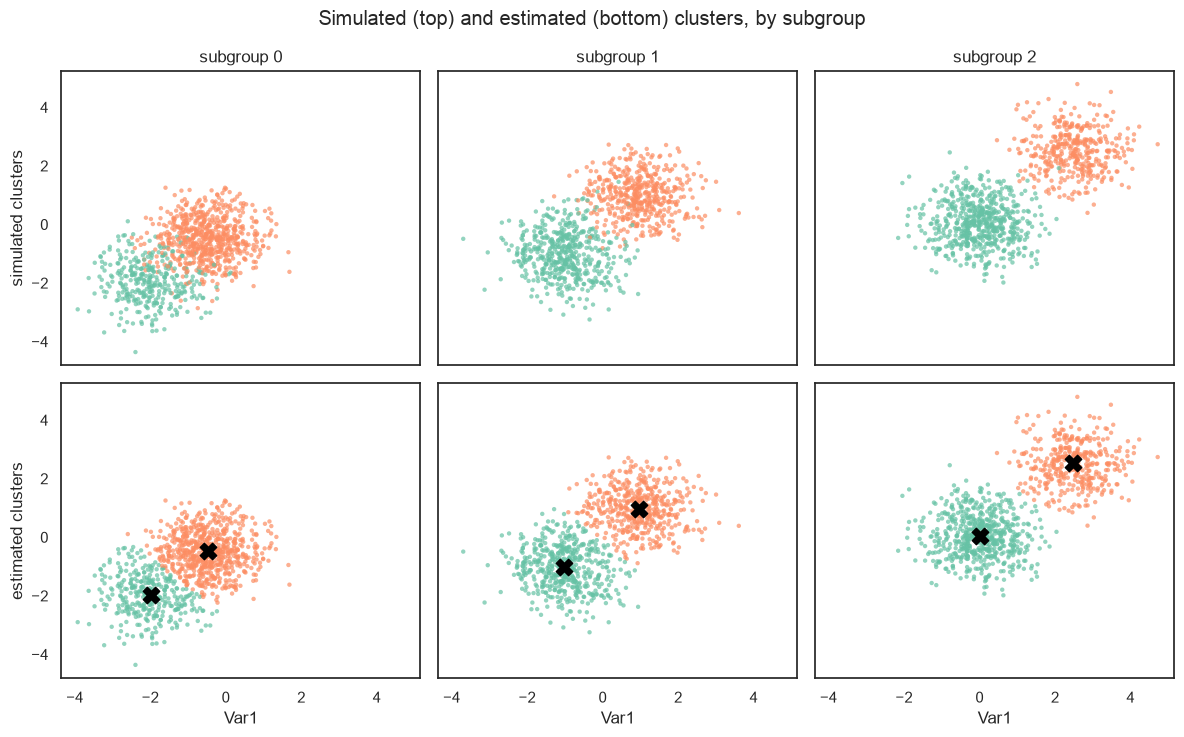

In [7]:
centres_posterior = np.asarray(mcmc.get_samples()["centres"]).mean(axis=0)
centres_posterior = centres_posterior[:, np.argsort(permutation), :]

fig, axes = plt.subplots(2, n_subgroups, figsize=(12, 7.5), sharex=True, sharey=True)
palette = sns.color_palette("Set2", n_clusters)

for row, column in enumerate(["cluster_true", "cluster_estimated"]):
    for j in range(n_subgroups):
        ax = axes[row, j]
        panel = data[data["subgroup"] == j]
        sns.scatterplot(
            data=panel,
            x="Var1",
            y="Var2",
            hue=column,
            hue_order=list(range(n_clusters)),
            palette=palette,
            s=10,
            linewidth=0,
            alpha=0.7,
            legend=False,
            ax=ax,
        )
        if row == 1:
            ax.scatter(*centres_posterior[j].T, marker="X", s=140, c="black", zorder=5)
        ax.set_title(f"subgroup {j}" if row == 0 else "")
        ax.set_ylabel(
            "simulated clusters"
            if (j == 0 and row == 0)
            else "estimated clusters"
            if j == 0
            else ""
        )

fig.suptitle("Simulated (top) and estimated (bottom) clusters, by subgroup")
fig.tight_layout()
plt.show()

## 5. Allocation probabilities

Rather than a hard assignment, the model returns a posterior probability of cluster
membership for every individual. The individuals with intermediate probabilities are
those in the region where the two clusters overlap.

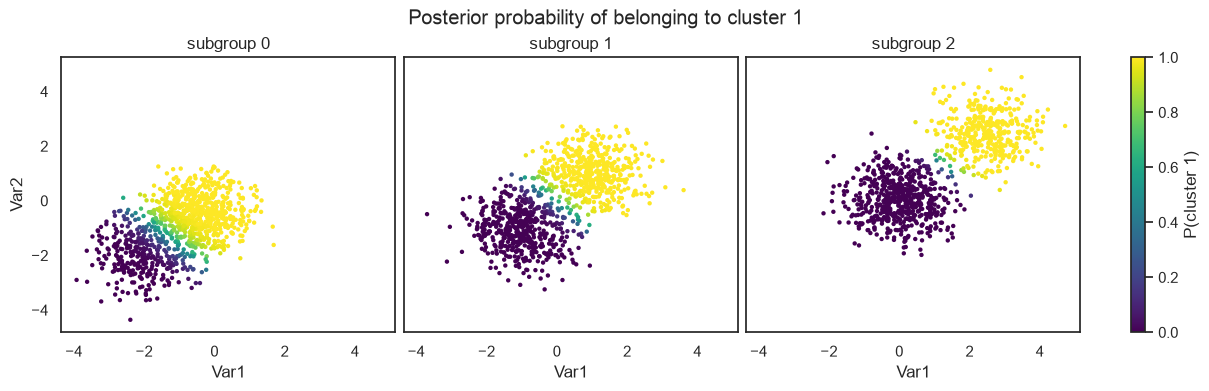

In [8]:
fig, axes = plt.subplots(
    1, n_subgroups, figsize=(12, 3.8), sharex=True, sharey=True, layout="constrained"
)

for j, ax in enumerate(axes):
    panel = data[data["subgroup"] == j]
    points = ax.scatter(
        panel["Var1"],
        panel["Var2"],
        c=panel["p_cluster_1"],
        cmap="viridis",
        vmin=0,
        vmax=1,
        s=10,
        linewidth=0,
    )
    ax.set_title(f"subgroup {j}")
    ax.set_xlabel("Var1")
    ax.set_ylabel("Var2" if j == 0 else "")

fig.colorbar(points, ax=axes, label="P(cluster 1)")
fig.suptitle("Posterior probability of belonging to cluster 1")
plt.show()

## 6. How well were the clusters recovered?

Allocation accuracy is the proportion of individuals assigned to their true cluster,
after the label matching above.

In [9]:
accuracy = accuracy_score(data["cluster_true"], data["cluster_estimated"])
print(f"allocation accuracy: {accuracy:.3f}\n")
print("confusion matrix (rows: simulated, columns: estimated)")
print(confusion_matrix(data["cluster_true"], data["cluster_estimated"]))
print()
print(classification_report(data["cluster_true"], data["cluster_estimated"], digits=3))

allocation accuracy: 0.970

confusion matrix (rows: simulated, columns: estimated)
[[1412   52]
 [  38 1498]]

              precision    recall  f1-score   support

           0      0.974     0.964     0.969      1464
           1      0.966     0.975     0.971      1536

    accuracy                          0.970      3000
   macro avg      0.970     0.970     0.970      3000
weighted avg      0.970     0.970     0.970      3000



The subgroup-specific weights are recovered as well. This is what makes the clusters
comparable across subgroups while allowing their prevalence to differ.

In [10]:
weights_posterior = np.asarray(mcmc.get_samples()["weights"]).mean(axis=0)
weights_posterior = weights_posterior[:, np.argsort(permutation)]

pd.DataFrame(
    {
        "simulated": weights_true.ravel(),
        "posterior mean": weights_posterior.ravel(),
    },
    index=pd.MultiIndex.from_product(
        [
            [f"subgroup {j}" for j in range(n_subgroups)],
            [f"cluster {k}" for k in range(n_clusters)],
        ]
    ),
).round(3)

simulated  posterior mean
subgroup 0 cluster 0      0.333           0.340
           cluster 1      0.667           0.660
subgroup 1 cluster 0      0.500           0.506
           cluster 1      0.500           0.494
subgroup 2 cluster 0      0.600           0.609
           cluster 1      0.400           0.391

## Notes

- The sensitivity analysis in the paper estimates a single shared diagonal,
  $V_k = \sigma R_k$ with $\sigma \sim \mathrm{HalfNormal}(1)$, instead of fixing it
  at $V_k = R_k / K$. Pass `estimate_diagonal=True` to switch to it:

  ```python
  mcmc = run_mcmc(y, subgroup, means, n_clusters, estimate_diagonal=True)
  allocations = posterior_allocations(
      mcmc, y, subgroup, means, n_clusters, estimate_diagonal=True
  )
  ```

- The analysis in the paper is much larger than this example: 10 risk factors,
  $K = 10$ clusters and 50 chains combined by consensus clustering. The script that
  produced it is in [`paper_analysis/`](../paper_analysis/).